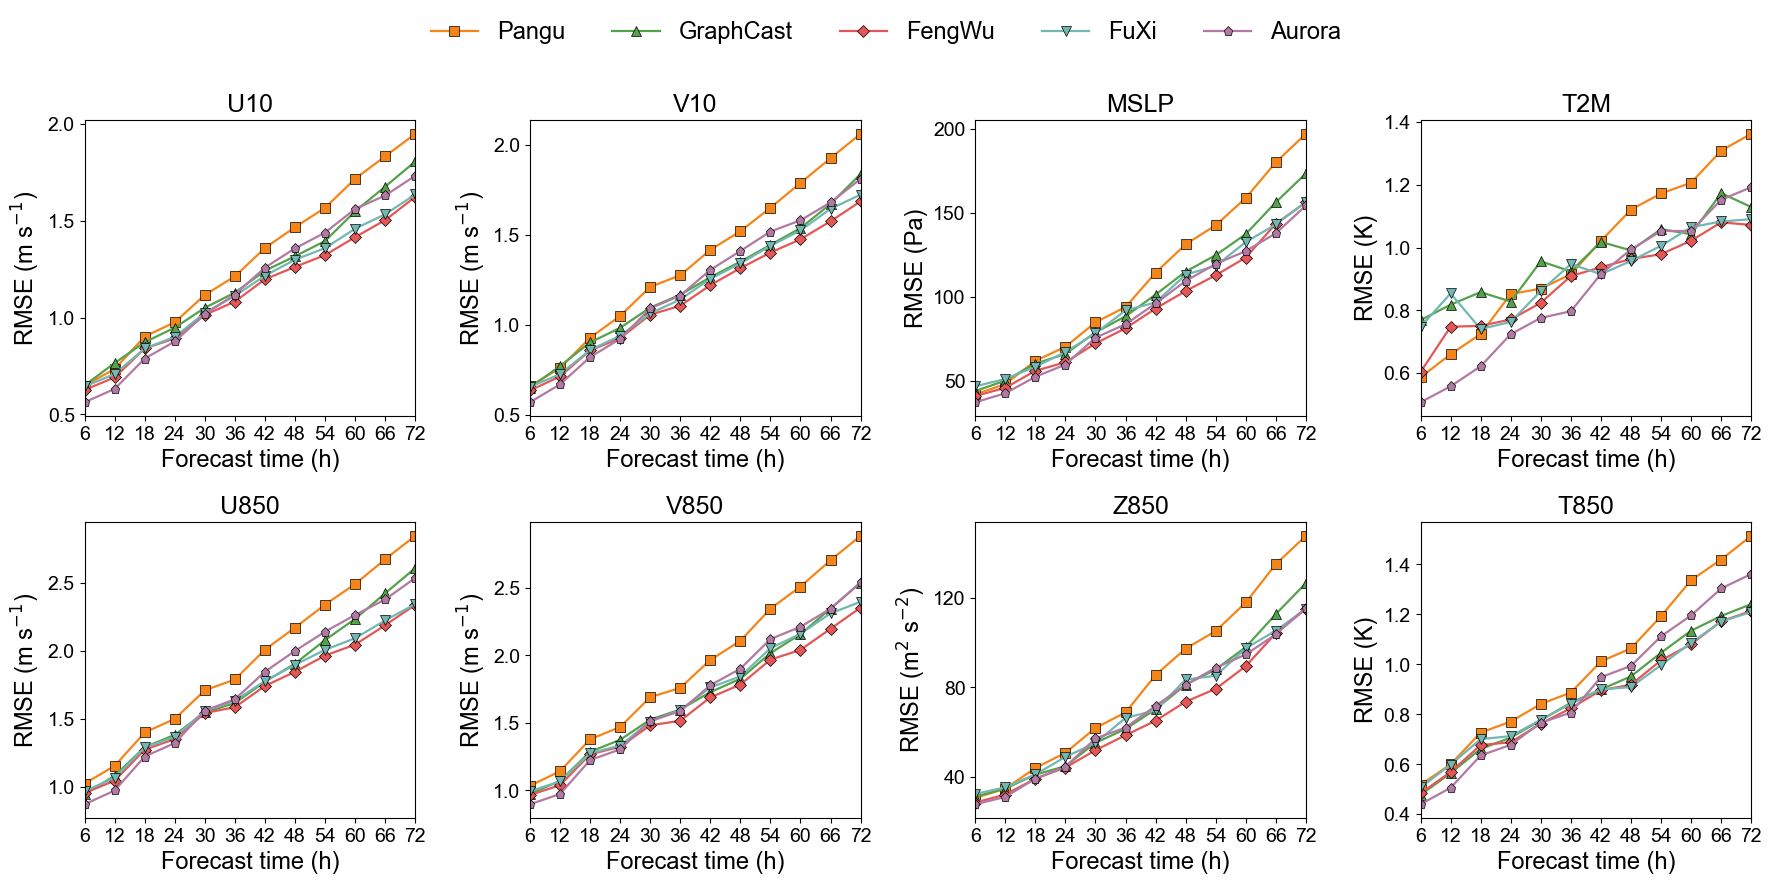

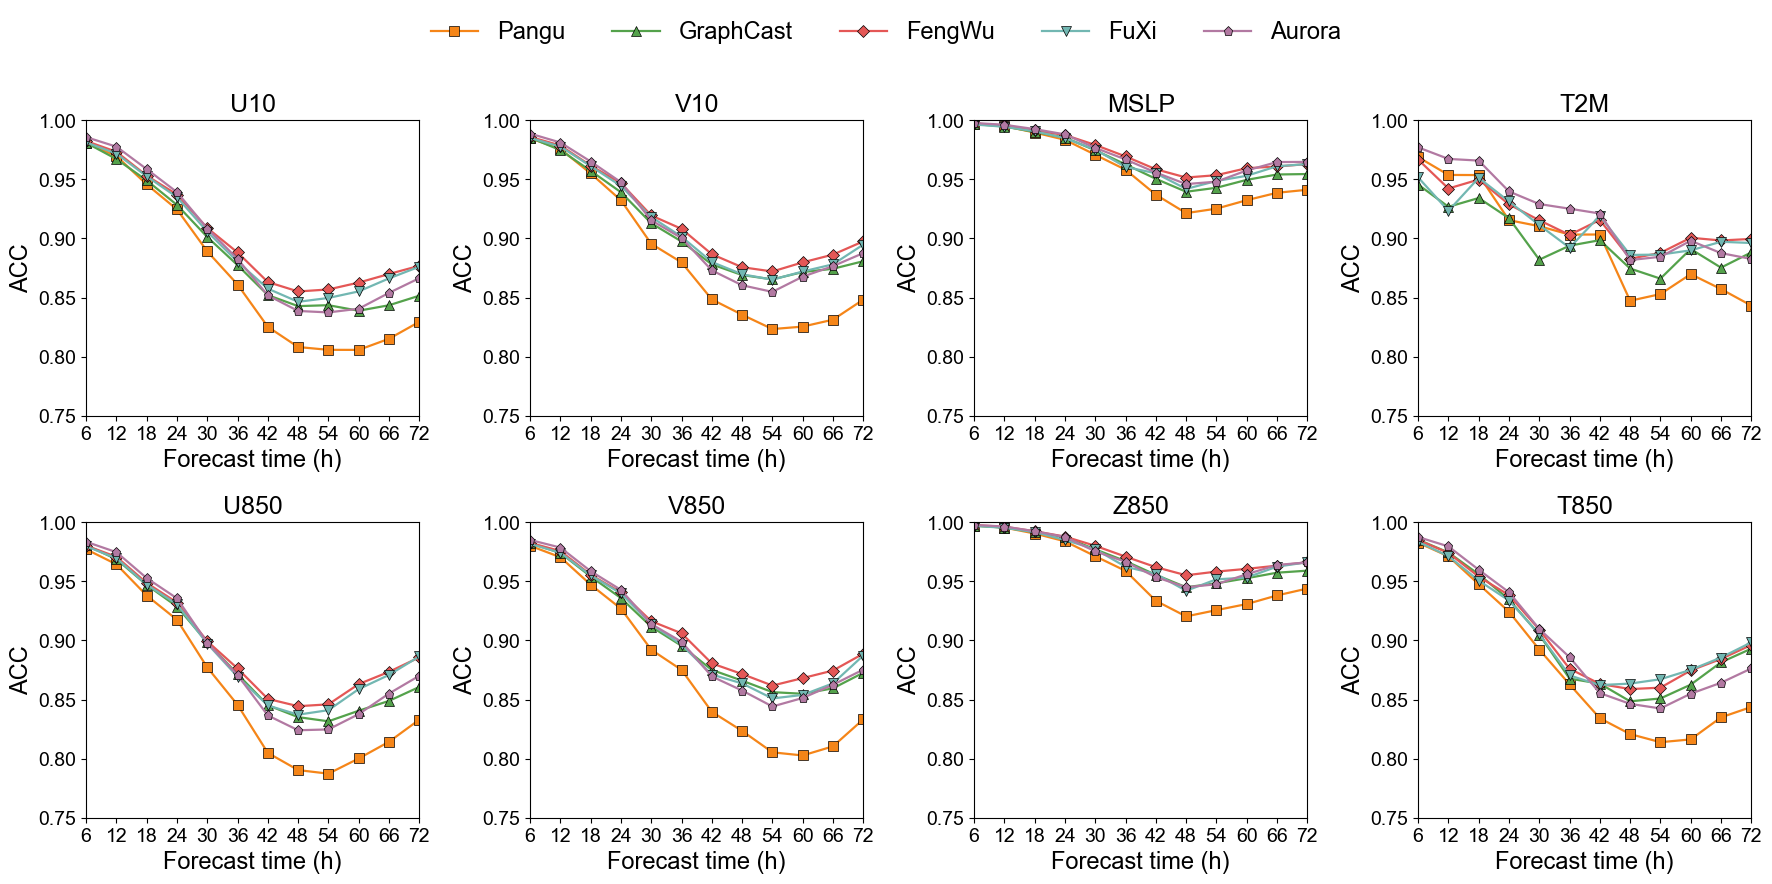

(      model  forecast_hour  valid_time variable        rmse
 0    aurora              6  2025092201     MSLP   37.249070
 1    aurora             12  2025092207     MSLP   42.601982
 2    aurora             18  2025092213     MSLP   52.424790
 3    aurora             24  2025092219     MSLP   59.761118
 4    aurora             30  2025092301     MSLP   75.735894
 ..      ...            ...         ...      ...         ...
 475   pangu             48  2025092319     Z850   97.318954
 476   pangu             54  2025092401     Z850  105.161224
 477   pangu             60  2025092407     Z850  117.916510
 478   pangu             66  2025092413     Z850  135.009430
 479   pangu             72  2025092419     Z850  147.684390
 
 [480 rows x 5 columns],
       model  forecast_hour  valid_time variable       acc
 0    aurora              6  2025092201     MSLP  0.997764
 1    aurora             12  2025092207     MSLP  0.996226
 2    aurora             18  2025092213     MSLP  0.992572
 3   

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, MaxNLocator, MultipleLocator

DATA_DIR = Path("./data")
OUTPUT_FILES = {
    "rmse": Path("rmse_all_variables_barplot.tif"),
    "acc": Path("acc_all_variables_barplot.tif"),
}

MODEL_STYLES = {
    "pangu": {"label": "Pangu", "color": "#f58518", "marker": "s"},
    "graphcast": {"label": "GraphCast", "color": "#54a24b", "marker": "^"},
    "fengwu": {"label": "FengWu", "color": "#e45756", "marker": "D"},
    "fuxi": {"label": "FuXi", "color": "#72b7b2", "marker": "v"},
    "aurora": {"label": "Aurora", "color": "#b279a2", "marker": "p"},
}

VARIABLE_METADATA = {
    "U10": {"title": "U10", "unit": "m s$^{-1}$"},
    "V10": {"title": "V10", "unit": "m s$^{-1}$"},
    "MSLP": {"title": "MSLP", "unit": "Pa"},
    "T2M": {"title": "T2M", "unit": "K"},
    "U850": {"title": "U850", "unit": "m s$^{-1}$"},
    "V850": {"title": "V850", "unit": "m s$^{-1}$"},
    "Z850": {"title": "Z850", "unit": "m$^2$ s$^{-2}$"},
    "T850": {"title": "T850", "unit": "K"},
}

PLOT_SETTINGS = {
    "figure_size": (18, 9),
    "title_fontsize": 18,
    "label_fontsize": 17,
    "text_fontsize": 14,
    "line_width": 1.6,
    "marker_size": 6.5,
    "acc_tick_step": 0.05,
    "rmse_sparse_integer_nbins": 4,
}

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 16,
})


def load_metric_table(metric_name):
    metric_frames = []

    for model_name in MODEL_STYLES:
        file_path = DATA_DIR / f"{model_name}_era5_{metric_name}.csv"
        metric_frame = pd.read_csv(file_path)
        metric_frame["model"] = model_name
        metric_frames.append(metric_frame)

    metric_table = pd.concat(metric_frames, ignore_index=True)
    metric_table["forecast_hour"] = pd.to_numeric(
        metric_table["forecast_hour"], errors="coerce"
    ).astype(int)

    value_columns = [column for column in metric_table.columns if column in VARIABLE_METADATA]
    return metric_table.melt(
        id_vars=["model", "forecast_hour", "valid_time"],
        value_vars=value_columns,
        var_name="variable",
        value_name=metric_name,
    )


def prepare_metric_summary(metric_name):
    return (
        load_metric_table(metric_name)
        .sort_values(["variable", "model", "forecast_hour"])
        .reset_index(drop=True)
    )


def rmse_tick_formatter(value, _position):
    return f"{value:.1f}"


def integer_tick_formatter(value, _position):
    return f"{value:.0f}"


def get_shared_acc_ticks(metric_summary_frame):
    tick_step = PLOT_SETTINGS["acc_tick_step"]
    acc_min = metric_summary_frame["acc"].min()
    acc_max = metric_summary_frame["acc"].max()
    lower = np.floor(acc_min / tick_step) * tick_step
    upper = np.ceil(acc_max / tick_step) * tick_step
    ticks = np.arange(lower, upper + tick_step * 0.5, tick_step)
    return lower, upper, np.round(ticks, 2)


def apply_rmse_axis_format(axis, variable_name):
    if variable_name in {"U10", "V10"}:
        axis.yaxis.set_major_locator(MultipleLocator(0.5))
        axis.yaxis.set_major_formatter(FuncFormatter(rmse_tick_formatter))
        return

    if variable_name in {"MSLP", "Z850"}:
        axis.yaxis.set_major_locator(
            MaxNLocator(
                integer=True,
                nbins=PLOT_SETTINGS["rmse_sparse_integer_nbins"],
            )
        )
        axis.yaxis.set_major_formatter(FuncFormatter(integer_tick_formatter))
        return

    axis.yaxis.set_major_formatter(FuncFormatter(rmse_tick_formatter))


def plot_variable_series(axis, variable_summary, metric_name, model_order):
    legend_handles = []

    for model_name in model_order:
        model_summary = (
            variable_summary.loc[variable_summary["model"] == model_name]
            .sort_values("forecast_hour")
            .reset_index(drop=True)
        )
        style = MODEL_STYLES[model_name]
        (line_handle,) = axis.plot(
            model_summary["forecast_hour"],
            model_summary[metric_name],
            label=style["label"],
            color=style["color"],
            marker=style["marker"],
            linewidth=PLOT_SETTINGS["line_width"],
            markersize=PLOT_SETTINGS["marker_size"],
            markeredgecolor="black",
            markeredgewidth=0.5,
        )
        legend_handles.append(line_handle)

    return legend_handles


def format_metric_axis(
    axis,
    metric_name,
    variable_name,
    forecast_hours,
    acc_limits=None,
    acc_ticks=None,
):
    variable_meta = VARIABLE_METADATA[variable_name]
    axis.set_title(variable_meta["title"], fontsize=PLOT_SETTINGS["title_fontsize"])
    axis.set_xlabel("Forecast time (h)", fontsize=PLOT_SETTINGS["label_fontsize"])

    if metric_name == "rmse":
        axis.set_ylabel(
            f"RMSE ({variable_meta['unit']})",
            fontsize=PLOT_SETTINGS["label_fontsize"],
        )
        apply_rmse_axis_format(axis, variable_name)
    else:
        axis.set_ylabel("ACC", fontsize=PLOT_SETTINGS["label_fontsize"])
        axis.set_ylim(*acc_limits)
        axis.set_yticks(acc_ticks)

    axis.set_xticks(forecast_hours)
    axis.tick_params(axis="x", labelsize=PLOT_SETTINGS["text_fontsize"])
    axis.tick_params(axis="y", labelsize=PLOT_SETTINGS["text_fontsize"])
    axis.grid(False)
    axis.set_xlim(min(forecast_hours), max(forecast_hours))


def plot_metric_summary(metric_summary_frame, metric_name, output_file):
    figure, axes = plt.subplots(2, 4, figsize=PLOT_SETTINGS["figure_size"])
    axes = axes.ravel()
    model_order = list(MODEL_STYLES)
    forecast_hours = sorted(metric_summary_frame["forecast_hour"].unique())

    acc_limits = None
    acc_ticks = None
    if metric_name == "acc":
        lower, upper, acc_ticks = get_shared_acc_ticks(metric_summary_frame)
        acc_limits = (lower, upper)

    legend_handles = []
    for axis_index, (axis, variable_name) in enumerate(zip(axes, VARIABLE_METADATA)):
        variable_summary = metric_summary_frame.loc[
            metric_summary_frame["variable"] == variable_name
        ]
        current_handles = plot_variable_series(
            axis, variable_summary, metric_name, model_order
        )
        if axis_index == 0:
            legend_handles = current_handles

        format_metric_axis(
            axis,
            metric_name,
            variable_name,
            forecast_hours,
            acc_limits=acc_limits,
            acc_ticks=acc_ticks,
        )

    figure.legend(
        legend_handles,
        [MODEL_STYLES[model_name]["label"] for model_name in model_order],
        loc="upper center",
        ncol=len(model_order),
        frameon=False,
        fontsize=PLOT_SETTINGS["label_fontsize"],
    )
    figure.tight_layout(rect=(0, 0, 1, 0.92))
    figure.savefig(output_file, dpi=600, format="tif", bbox_inches="tight")
    return figure, axes


def generate_metric_plots():
    rmse_summary = prepare_metric_summary("rmse")
    acc_summary = prepare_metric_summary("acc")

    rmse_fig, rmse_axes = plot_metric_summary(
        rmse_summary,
        "rmse",
        OUTPUT_FILES["rmse"],
    )
    plt.show()

    acc_fig, acc_axes = plot_metric_summary(
        acc_summary,
        "acc",
        OUTPUT_FILES["acc"],
    )
    plt.show()

    return rmse_summary, acc_summary, rmse_fig, rmse_axes, acc_fig, acc_axes


rmse_summary, acc_summary, rmse_fig, rmse_axes, acc_fig, acc_axes = generate_metric_plots()

rmse_summary, acc_summary

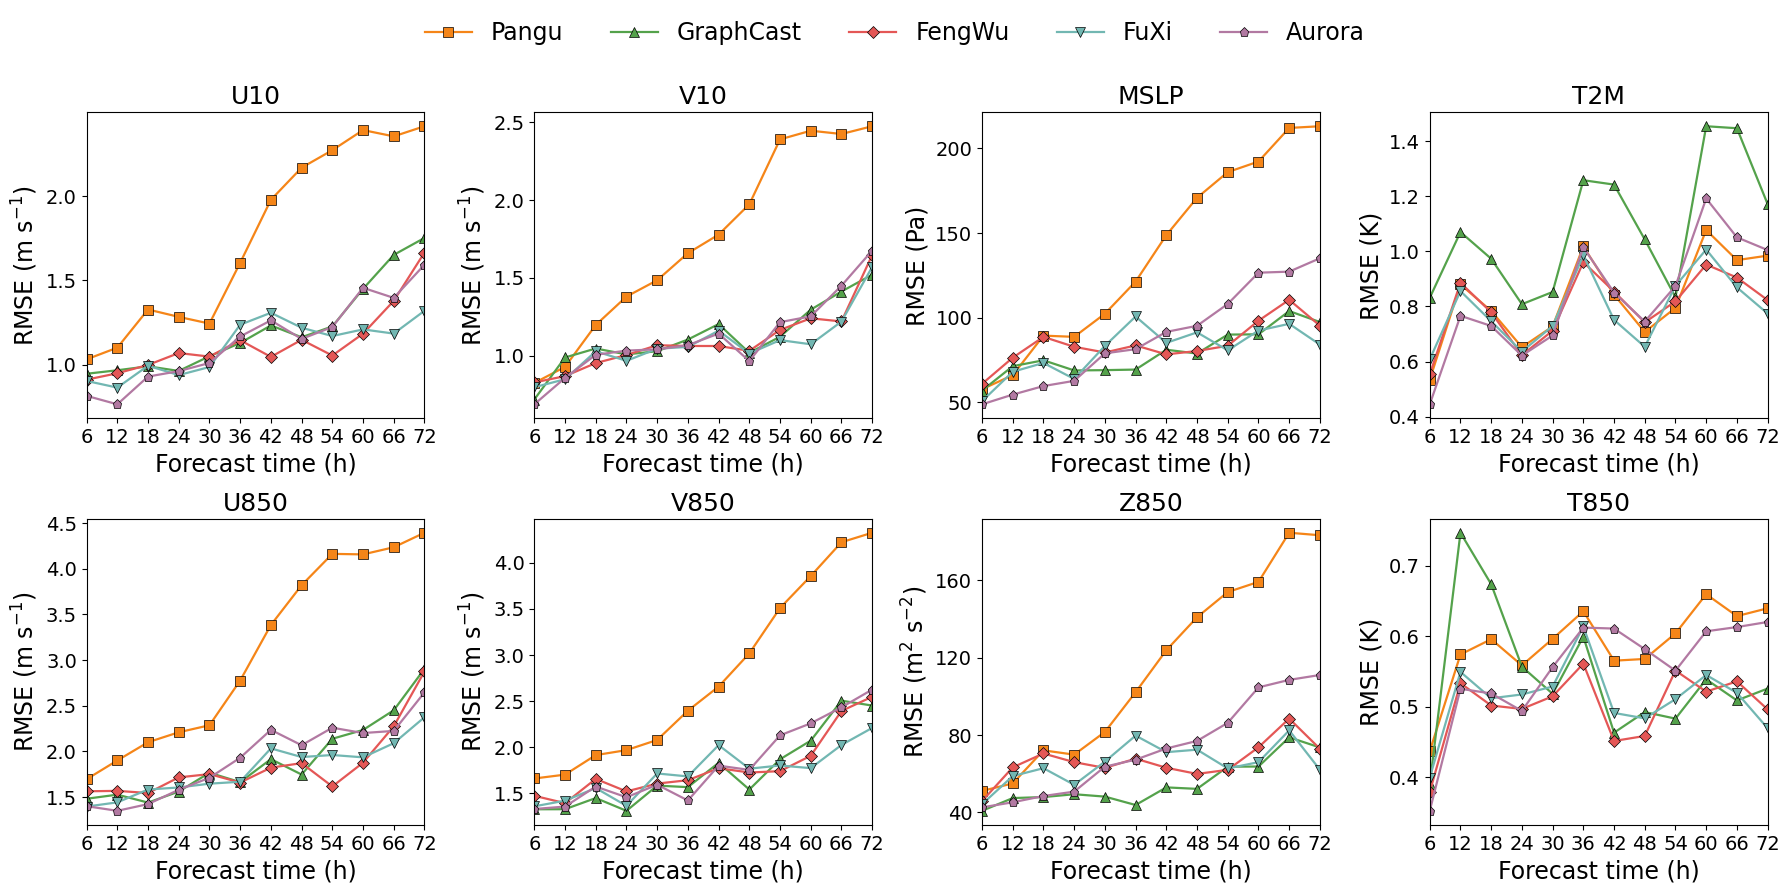

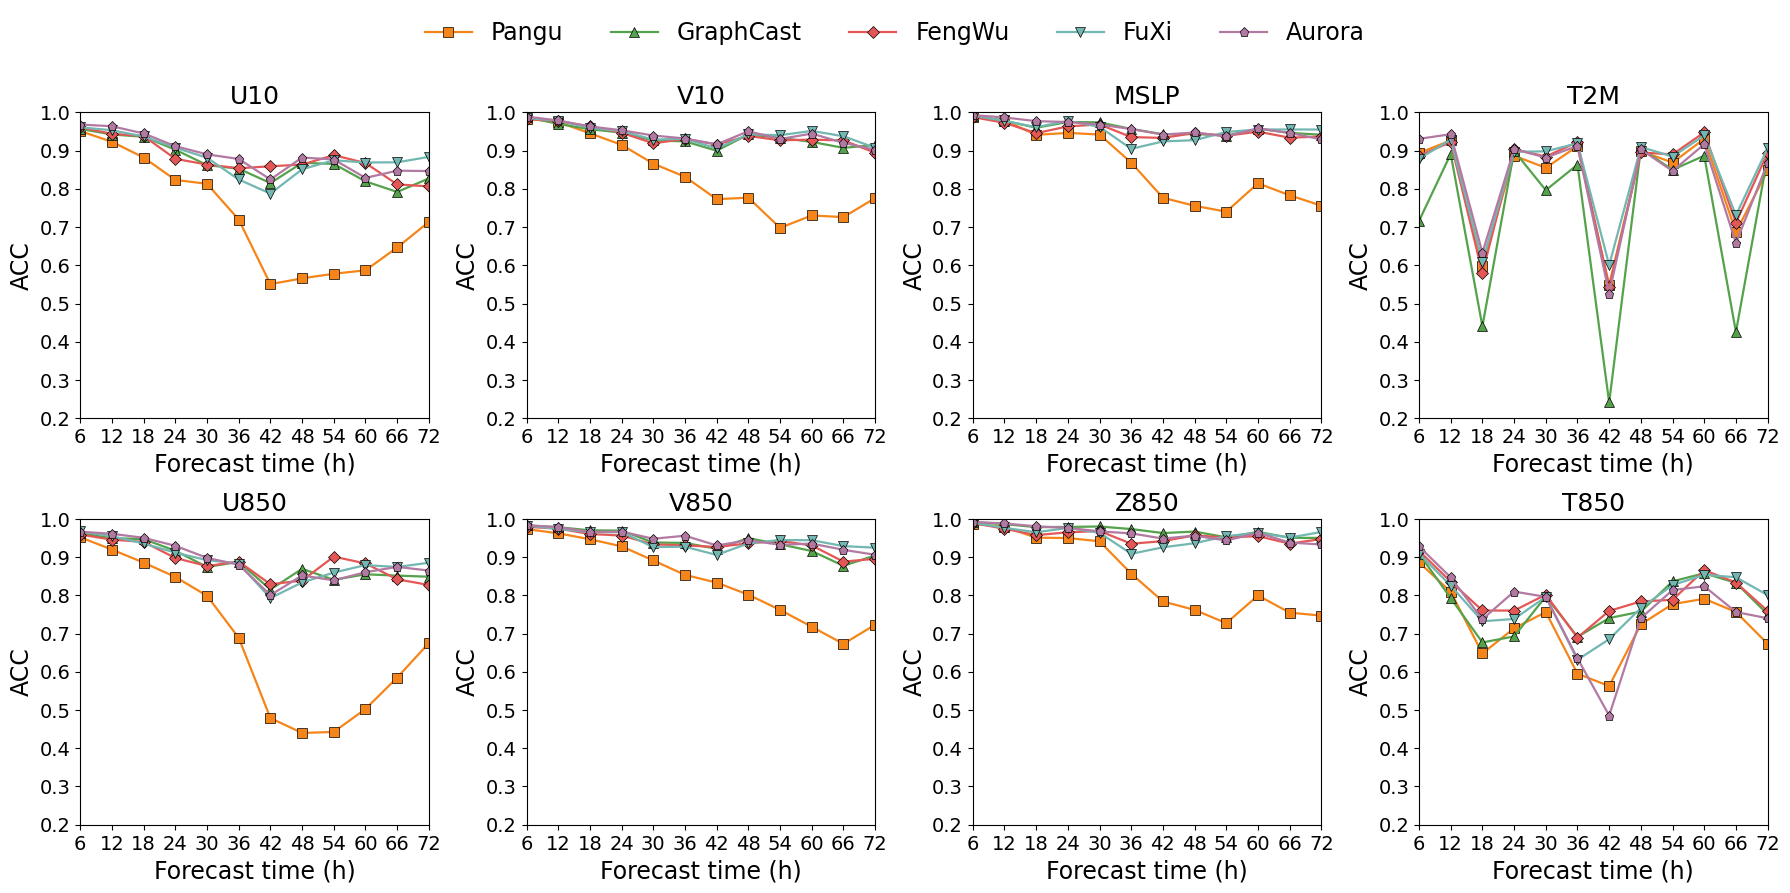

(      model  forecast_hour  valid_time variable        rmse
 0    aurora              6  2025092201     MSLP   48.711118
 1    aurora             12  2025092207     MSLP   54.447770
 2    aurora             18  2025092213     MSLP   59.501855
 3    aurora             24  2025092219     MSLP   62.574568
 4    aurora             30  2025092301     MSLP   78.830138
 ..      ...            ...         ...      ...         ...
 475   pangu             48  2025092319     Z850  140.949663
 476   pangu             54  2025092401     Z850  153.978980
 477   pangu             60  2025092407     Z850  159.237529
 478   pangu             66  2025092413     Z850  184.648539
 479   pangu             72  2025092419     Z850  183.344831
 
 [480 rows x 5 columns],
       model  forecast_hour  valid_time variable       acc
 0    aurora              6  2025092201     MSLP  0.992621
 1    aurora             12  2025092207     MSLP  0.986622
 2    aurora             18  2025092213     MSLP  0.976969
 3   

In [2]:
# === d01 区域：RMSE / ACC（与上面同方法、同风格）===

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, MaxNLocator, MultipleLocator

# 允许只运行本 cell：如果上面 cell 没跑过，就补齐必要常量/函数
if "DATA_DIR" not in globals():
    DATA_DIR = Path("./data")

if "MODEL_STYLES" not in globals():
    MODEL_STYLES = {
        "pangu": {"label": "Pangu", "color": "#f58518", "marker": "s"},
        "graphcast": {"label": "GraphCast", "color": "#54a24b", "marker": "^"},
        "fengwu": {"label": "FengWu", "color": "#e45756", "marker": "D"},
        "fuxi": {"label": "FuXi", "color": "#72b7b2", "marker": "v"},
        "aurora": {"label": "Aurora", "color": "#b279a2", "marker": "p"},
    }

if "VARIABLE_METADATA" not in globals():
    VARIABLE_METADATA = {
        "U10": {"title": "U10", "unit": "m s$^{-1}$"},
        "V10": {"title": "V10", "unit": "m s$^{-1}$"},
        "MSLP": {"title": "MSLP", "unit": "Pa"},
        "T2M": {"title": "T2M", "unit": "K"},
        "U850": {"title": "U850", "unit": "m s$^{-1}$"},
        "V850": {"title": "V850", "unit": "m s$^{-1}$"},
        "Z850": {"title": "Z850", "unit": "m$^2$ s$^{-2}$"},
        "T850": {"title": "T850", "unit": "K"},
    }

if "PLOT_SETTINGS" not in globals():
    PLOT_SETTINGS = {
        "figure_size": (18, 9),
        "title_fontsize": 18,
        "label_fontsize": 17,
        "text_fontsize": 14,
        "line_width": 1.6,
        "marker_size": 6.5,
        "acc_tick_step": 0.05,
        "rmse_sparse_integer_nbins": 4,
    }

# ACC 纵坐标刻度：更稀疏一些（避免过密）
PLOT_SETTINGS["acc_tick_step"] = 0.1

if "plot_metric_summary" not in globals():
    def rmse_tick_formatter(value, _position):
        return f"{value:.1f}"

    def integer_tick_formatter(value, _position):
        return f"{value:.0f}"

    def get_shared_acc_ticks(metric_summary_frame):
        tick_step = PLOT_SETTINGS["acc_tick_step"]
        acc_min = metric_summary_frame["acc"].min()
        acc_max = metric_summary_frame["acc"].max()
        lower = np.floor(acc_min / tick_step) * tick_step
        upper = np.ceil(acc_max / tick_step) * tick_step
        ticks = np.arange(lower, upper + tick_step * 0.5, tick_step)
        return lower, upper, np.round(ticks, 2)

    def apply_rmse_axis_format(axis, variable_name):
        if variable_name in {"U10", "V10"}:
            axis.yaxis.set_major_locator(MultipleLocator(0.5))
            axis.yaxis.set_major_formatter(FuncFormatter(rmse_tick_formatter))
            return

        if variable_name in {"MSLP", "Z850"}:
            axis.yaxis.set_major_locator(
                MaxNLocator(
                    integer=True,
                    nbins=PLOT_SETTINGS["rmse_sparse_integer_nbins"],
                )
            )
            axis.yaxis.set_major_formatter(FuncFormatter(integer_tick_formatter))
            return

        axis.yaxis.set_major_formatter(FuncFormatter(rmse_tick_formatter))

    def plot_variable_series(axis, variable_summary, metric_name, model_order):
        legend_handles = []

        for model_name in model_order:
            model_summary = (
                variable_summary.loc[variable_summary["model"] == model_name]
                .sort_values("forecast_hour")
                .reset_index(drop=True)
            )
            style = MODEL_STYLES[model_name]
            (line_handle,) = axis.plot(
                model_summary["forecast_hour"],
                model_summary[metric_name],
                label=style["label"],
                color=style["color"],
                marker=style["marker"],
                linewidth=PLOT_SETTINGS["line_width"],
                markersize=PLOT_SETTINGS["marker_size"],
                markeredgecolor="black",
                markeredgewidth=0.5,
            )
            legend_handles.append(line_handle)

        return legend_handles

    def format_metric_axis(
        axis,
        metric_name,
        variable_name,
        forecast_hours,
        acc_limits=None,
        acc_ticks=None,
    ):
        variable_meta = VARIABLE_METADATA[variable_name]
        axis.set_title(variable_meta["title"], fontsize=PLOT_SETTINGS["title_fontsize"])
        axis.set_xlabel("Forecast time (h)", fontsize=PLOT_SETTINGS["label_fontsize"])

        if metric_name == "rmse":
            axis.set_ylabel(
                f"RMSE ({variable_meta['unit']})",
                fontsize=PLOT_SETTINGS["label_fontsize"],
            )
            apply_rmse_axis_format(axis, variable_name)
        else:
            axis.set_ylabel("ACC", fontsize=PLOT_SETTINGS["label_fontsize"])
            axis.set_ylim(*acc_limits)
            axis.set_yticks(acc_ticks)

        axis.set_xticks(forecast_hours)
        axis.tick_params(axis="x", labelsize=PLOT_SETTINGS["text_fontsize"])
        axis.tick_params(axis="y", labelsize=PLOT_SETTINGS["text_fontsize"])
        axis.grid(False)
        axis.set_xlim(min(forecast_hours), max(forecast_hours))

    def plot_metric_summary(metric_summary_frame, metric_name, output_file):
        figure, axes = plt.subplots(2, 4, figsize=PLOT_SETTINGS["figure_size"])
        axes = axes.ravel()
        model_order = list(MODEL_STYLES)
        forecast_hours = sorted(metric_summary_frame["forecast_hour"].unique())

        acc_limits = None
        acc_ticks = None
        if metric_name == "acc":
            lower, upper, acc_ticks = get_shared_acc_ticks(metric_summary_frame)
            acc_limits = (lower, upper)

        legend_handles = []
        for axis_index, (axis, variable_name) in enumerate(zip(axes, VARIABLE_METADATA)):
            variable_summary = metric_summary_frame.loc[
                metric_summary_frame["variable"] == variable_name
            ]
            current_handles = plot_variable_series(
                axis, variable_summary, metric_name, model_order
            )
            if axis_index == 0:
                legend_handles = current_handles

            format_metric_axis(
                axis,
                metric_name,
                variable_name,
                forecast_hours,
                acc_limits=acc_limits,
                acc_ticks=acc_ticks,
            )

        figure.legend(
            legend_handles,
            [MODEL_STYLES[model_name]["label"] for model_name in model_order],
            loc="upper center",
            ncol=len(model_order),
            frameon=False,
            fontsize=PLOT_SETTINGS["label_fontsize"],
        )
        figure.tight_layout(rect=(0, 0, 1, 0.92))
        figure.savefig(output_file, dpi=600, format="tif", bbox_inches="tight")
        return figure, axes


def load_metric_table_region(metric_name, file_suffix):
    metric_frames = []

    for model_name in MODEL_STYLES:
        file_path = DATA_DIR / f"{model_name}_era5_{metric_name}{file_suffix}.csv"
        if not file_path.exists():
            raise FileNotFoundError(f"Missing file: {file_path}")
        metric_frame = pd.read_csv(file_path)
        metric_frame["model"] = model_name
        metric_frames.append(metric_frame)

    metric_table = pd.concat(metric_frames, ignore_index=True)
    metric_table["forecast_hour"] = pd.to_numeric(
        metric_table["forecast_hour"], errors="coerce"
    ).astype(int)

    value_columns = [column for column in metric_table.columns if column in VARIABLE_METADATA]
    return metric_table.melt(
        id_vars=["model", "forecast_hour", "valid_time"],
        value_vars=value_columns,
        var_name="variable",
value_name=metric_name,
    )


def prepare_metric_summary_region(metric_name, file_suffix):
    return (
        load_metric_table_region(metric_name, file_suffix)
        .sort_values(["variable", "model", "forecast_hour"])
        .reset_index(drop=True)
    )


D01_SUFFIX = "_d01"
OUTPUT_FILES_D01 = {
    "rmse": Path("rmse_all_variables_barplot_d01.tif"),
    "acc": Path("acc_all_variables_barplot_d01.tif"),
}

rmse_summary_d01 = prepare_metric_summary_region("rmse", D01_SUFFIX)
acc_summary_d01 = prepare_metric_summary_region("acc", D01_SUFFIX)

rmse_fig_d01, rmse_axes_d01 = plot_metric_summary(
    rmse_summary_d01, "rmse", OUTPUT_FILES_D01["rmse"]
 )
plt.show()

acc_fig_d01, acc_axes_d01 = plot_metric_summary(
    acc_summary_d01, "acc", OUTPUT_FILES_D01["acc"]
 )
plt.show()

rmse_summary_d01, acc_summary_d01